# Semana 3 Clase 2

## Primer modelo predictivo con regresión lineal

Pasaremos de:

$$
\text{preparación de datos}
$$

a:

$$
\text{predicción de casos futuros}.
$$


Construiremos un primer modelo predictivo para estimar los casos de la siguiente semana usando variables derivadas de la serie temporal:

$$
C_{t+1}=f(C_t,C_{t-1},C_{t-2},C_{t-3},MA_3).
$$

Buscamos predecir $C_{t+1}$ usando información disponible hasta la semana $t$, sin usar datos del futuro.

Utilizaremos las siguientes variables porque estamos tratando la serie de casos semanales como una variable que depende de su propio comportamiento pasado.


### 1. $C_t$: casos de la semana actual

Usamos $C_t$ porque la semana actual suele ser la información más cercana para predecir la siguiente semana.

Si esta semana hay muchos casos, es razonable pensar que la próxima semana también podría haber muchos, especialmente si el brote sigue activo.

Por ejemplo:

$$
C_t = \text{casos de esta semana}.
$$

La predicción ingenua más simple sería:

$$
\widehat{C}_{t+1}=C_t.
$$

Es decir, asumir que la próxima semana será parecida a la actual.


### 2. $C_{t-1}, C_{t-2}, C_{t-3}$: rezagos

Los rezagos representan el historial reciente de la serie:

$$
C_{t-1}=\text{casos de una semana antes},
$$

$$
C_{t-2}=\text{casos de dos semanas antes},
$$

$$
C_{t-3}=\text{casos de tres semanas antes}.
$$

Los usamos porque en un brote epidemiológico el valor de una semana no aparece aislado: normalmente depende de lo que ocurrió en semanas anteriores.

Por ejemplo, si tenemos:

$$
C_{t-3}=20,\quad C_{t-2}=50,\quad C_{t-1}=120,\quad C_t=250,
$$

entonces vemos una tendencia creciente. Eso sugiere que $C_{t+1}$ podría seguir aumentando.

Pero si tenemos:

$$
C_{t-3}=300,\quad C_{t-2}=200,\quad C_{t-1}=120,\quad C_t=60,
$$

entonces vemos una tendencia descendente. Eso sugiere que $C_{t+1}$ podría disminuir.

Los rezagos ayudan al modelo a reconocer si la serie viene subiendo, bajando o estabilizándose.



### 3. $MA_3$: promedio móvil de 3 semanas

El promedio móvil de 3 semanas se define como:

$$
MA_3(t)=\frac{C_t+C_{t-1}+C_{t-2}}{3}.
$$

Lo usamos porque resume la tendencia reciente de la serie y reduce fluctuaciones muy bruscas.

Por ejemplo, si una semana tuvo un valor atípicamente alto o bajo, el promedio móvil suaviza ese efecto.

En datos epidemiológicos esto es útil porque los casos reportados pueden variar por retrasos de notificación, fines de semana, acumulación de registros o ruido administrativo.


### Cuidado 

Estas variables son una primera aproximación. No significan que el modelo sea epidemiológicamente completo.

Faltan factores como:

* población susceptible;
* vacunación;
* movilidad;
* estructura por municipios;
* retrasos de notificación;
* intervención sanitaria;
* contactos entre personas;
* cambios en el comportamiento.

Pero para una primer  modelo predictivo, estas variables son adecuadas porque muestran cómo convertir una serie temporal en una tabla para predicción.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ruta = "https://raw.githubusercontent.com/jamc88/Taller-Modelado-I/refs/heads/main/Datos/serie_chihuahua_completa.csv"
df = pd.read_csv(ruta)

df["SEMANA_DIAG"] = pd.to_datetime(df["SEMANA_DIAG"])

cols_municipios = [col for col in df.columns if col != "SEMANA_DIAG"]

df["casos_semana"] = df[cols_municipios].sum(axis=1)

df = df.sort_values("SEMANA_DIAG").reset_index(drop=True)

df.head()

,SEMANA_DIAG,AHUMADA,ALDAMA,ALLENDE,AQUILES SERDÁN,ASCENSIÓN,BACHÍNIVA,BALLEZA,BATOPILAS DE MANUEL GÓMEZ MORÍN,BOCOYNA,...,RIVA PALACIO,ROSALES,SAN FRANCISCO DE BORJA,SAN FRANCISCO DE CONCHOS,SANTA ISABEL,SAUCILLO,TEMÓSACHIC,URIQUE,URUACHI,casos_semana
0,2025-02-24,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
1,2025-03-03,0,0,0,0,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,4
2,2025-03-10,0,0,0,0,0,0,0,0,0,...,10,0,0,0,0,0,0,0,0,31
3,2025-03-17,0,0,0,0,0,1,0,0,0,...,3,0,0,0,0,0,0,0,0,29
4,2025-03-24,8,0,0,0,0,2,0,0,0,...,8,0,0,0,0,0,0,0,0,89


### Construimos variables predictoras

In [4]:
df["lag_1"] = df["casos_semana"].shift(1)
df["lag_2"] = df["casos_semana"].shift(2)
df["lag_3"] = df["casos_semana"].shift(3)

df["promedio_movil_3"] = df["casos_semana"].rolling(window=3).mean()
df["promedio_movil_5"] = df["casos_semana"].rolling(window=5).mean()

df["cambio_semanal"] = df["casos_semana"].diff()

df["casos_siguiente_semana"] = df["casos_semana"].shift(-1)

df.head()

,SEMANA_DIAG,AHUMADA,ALDAMA,ALLENDE,AQUILES SERDÁN,ASCENSIÓN,BACHÍNIVA,BALLEZA,BATOPILAS DE MANUEL GÓMEZ MORÍN,BOCOYNA,...,URIQUE,URUACHI,casos_semana,lag_1,lag_2,lag_3,promedio_movil_3,promedio_movil_5,cambio_semanal,casos_siguiente_semana
0,2025-02-24,0,0,0,0,0,0,0,0,0,...,0,0,3,NaN,NaN,NaN,NaN,NaN,NaN,4.0
1,2025-03-03,0,0,0,0,0,0,0,0,0,...,0,0,4,3.0,NaN,NaN,NaN,NaN,1.0,31.0
2,2025-03-10,0,0,0,0,0,0,0,0,0,...,0,0,31,4.0,3.0,NaN,12.666667,NaN,27.0,29.0
3,2025-03-17,0,0,0,0,0,1,0,0,0,...,0,0,29,31.0,4.0,3.0,21.333333,NaN,-2.0,89.0
4,2025-03-24,8,0,0,0,0,2,0,0,0,...,0,0,89,29.0,31.0,4.0,49.666667,31.2,60.0,109.0


### Preparamos la tabla final para modelado

In [6]:
columnas_modelo = [
    "SEMANA_DIAG",
    "casos_semana",
    "lag_1",
    "lag_2",
    "lag_3",
    "promedio_movil_3",
    "promedio_movil_5",
    "cambio_semanal",
    "casos_siguiente_semana"
]

df_modelo = df[columnas_modelo].dropna().reset_index(drop=True)

df_modelo.head()

,SEMANA_DIAG,casos_semana,lag_1,lag_2,lag_3,promedio_movil_3,promedio_movil_5,cambio_semanal,casos_siguiente_semana
0,2025-03-24,89,29.0,31.0,4.0,49.666667,31.2,60.0,109.0
1,2025-03-31,109,89.0,29.0,31.0,75.666667,52.4,20.0,207.0
2,2025-04-07,207,109.0,89.0,29.0,135.000000,93.0,98.0,160.0
3,2025-04-14,160,207.0,109.0,89.0,158.666667,118.8,-47.0,226.0
4,2025-04-21,226,160.0,207.0,109.0,197.666667,158.2,66.0,234.0


$$
X = \text{información disponible hasta la semana } t,
$$

$$
y = \text{casos observados en la semana } t+1.
$$

### Definimos $X$ y $y$

In [7]:
variables_predictoras = [
    "casos_semana",
    "lag_1",
    "lag_2",
    "lag_3",
    "promedio_movil_3",
    "promedio_movil_5",
    "cambio_semanal"
]

X = df_modelo[variables_predictoras]
y = df_modelo["casos_siguiente_semana"]

print(X.head())
print(y.head())

   casos_semana  lag_1  lag_2  lag_3  promedio_movil_3  promedio_movil_5  \
0            89   29.0   31.0    4.0         49.666667              31.2   
1           109   89.0   29.0   31.0         75.666667              52.4   
2           207  109.0   89.0   29.0        135.000000              93.0   
3           160  207.0  109.0   89.0        158.666667             118.8   
4           226  160.0  207.0  109.0        197.666667             158.2   

   cambio_semanal  
0            60.0  
1            20.0  
2            98.0  
3           -47.0  
4            66.0  
0    109.0
1    207.0
2    160.0
3    226.0
4    234.0
Name: casos_siguiente_semana, dtype: float64


### División temporal en entrenamiento y prueba

En series de tiempo no conviene hacer una división aleatoria. Debemos respetar el orden cronológico.


In [8]:
n = len(df_modelo)

n_train = int(0.7 * n)

df_train = df_modelo.iloc[:n_train].copy()
df_test = df_modelo.iloc[n_train:].copy()

X_train = df_train[variables_predictoras]
y_train = df_train["casos_siguiente_semana"]

X_test = df_test[variables_predictoras]
y_test = df_test["casos_siguiente_semana"]

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

Tamaño entrenamiento: (39, 7)
Tamaño prueba: (17, 7)


### Visualizar entrenamiento y prueba


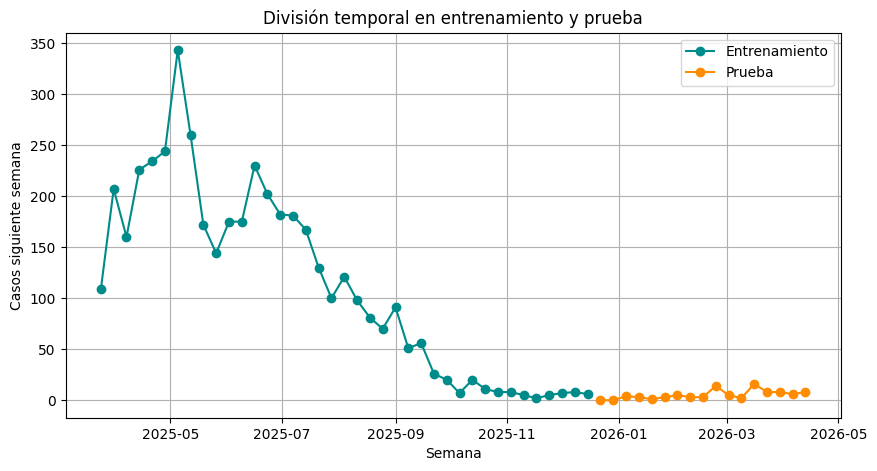

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_train["SEMANA_DIAG"],
    df_train["casos_siguiente_semana"],
    marker="o",
    label="Entrenamiento",
    color="darkcyan"
)

plt.plot(
    df_test["SEMANA_DIAG"],
    df_test["casos_siguiente_semana"],
    marker="o",
    label="Prueba",
    color="darkorange"
)

plt.xlabel("Semana")
plt.ylabel("Casos siguiente semana")
plt.title("División temporal en entrenamiento y prueba")
plt.xticks()
plt.legend()
plt.grid()

plt.show()

### Modelo base: predicción ingenua

Antes de usar regresión lineal, construimos un modelo muy simple:

$$
\widehat{C}_{t+1}=C_t.
$$

Es decir, suponemos que los casos de la siguiente semana serán iguales a los de la semana actual.

In [11]:
df_test["pred_naive"] = df_test["casos_semana"]

df_test[[
    "SEMANA_DIAG",
    "casos_semana",
    "casos_siguiente_semana",
    "pred_naive"
]]

,SEMANA_DIAG,casos_semana,casos_siguiente_semana,pred_naive
39,2025-12-22,6,0.0,6
40,2025-12-29,0,0.0,0
41,2026-01-05,0,4.0,0
42,2026-01-12,4,3.0,4
43,2026-01-19,3,1.0,3
44,2026-01-26,1,3.0,1
45,2026-02-02,3,5.0,3
46,2026-02-09,5,3.0,5
47,2026-02-16,3,3.0,3
48,2026-02-23,3,14.0,3


### Métricas de error

Usaremos:

$$
MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat y_i|
$$

y

$$
RMSE=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2}.
$$

In [12]:
def calcular_metricas(y_real, y_pred):
    error = y_real - y_pred
    
    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error**2))
    
    return mae, rmse

In [13]:
mae_naive, rmse_naive = calcular_metricas(
    df_test["casos_siguiente_semana"],
    df_test["pred_naive"]
)

In [14]:
print("Modelo ingenuo")
print("MAE:", mae_naive)
print("RMSE:", rmse_naive)

Modelo ingenuo
MAE: 4.0
RMSE: 5.67761341741819


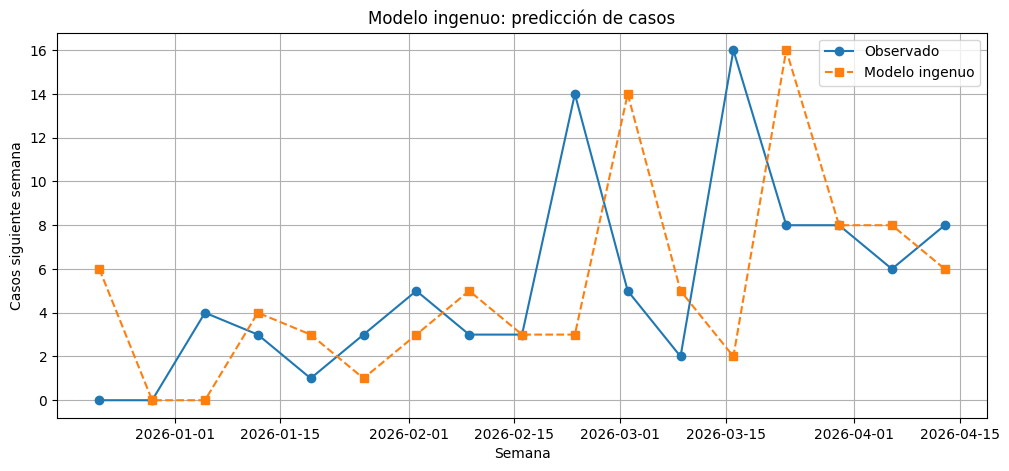

In [15]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_test["SEMANA_DIAG"],
    df_test["casos_siguiente_semana"],
    marker="o",
    label="Observado"
)

plt.plot(
    df_test["SEMANA_DIAG"],
    df_test["pred_naive"],
    marker="s",
    linestyle="--",
    label="Modelo ingenuo"
)

plt.xlabel("Semana")
plt.ylabel("Casos siguiente semana")
plt.title("Modelo ingenuo: predicción de casos")
plt.legend()
plt.grid()

plt.show()

## Regresión lineal Múltiple

La **Regresión Lineal Múltiple** es una técnica que busca predecir el valor de una variable dependiente combinando linealmente múltiples variables independientes. Asume que el resultado final es la suma de los efectos individuales de cada predictor.

La fórmula genérica:

$$\widehat{y} = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_px_p$$

Al aterrizar esta fórmula matemática al escenario de predicción de casos de sarampión, el modelo queda estructurado así:

$$\widehat{C}_{t+1} = \beta_0 + \beta_1C_t + \beta_2C_{t-1} + \beta_3C_{t-2} + \beta_4C_{t-3} + \beta_5MA_3$$

Donde

* **$\widehat{C}_{t+1}$:** Es el objetivo de nuestra predicción (El número estimado de casos para la próxima semana).
* **$\beta_0$ (Intercepto):** Es el nivel base del modelo. Matemáticamente, representa el número de casos que esperaríamos si todas las demás variables (rezagos y promedios) fueran exactamente cero.
* **$C_t, C_{t-1}, C_{t-2}, C_{t-3}, MA_3$ (Predictores):**  Representan el contexto temporal y la tendencia de la curva epidémica que alimentan la predicción.
* **$\beta_1, \beta_2, \beta_3, \beta_4, \beta_5$ (Coeficientes o Pesos):** Este es el núcleo del aprendizaje automático. Al entrenar el modelo con tus datos históricos, el algoritmo calculará el valor óptimo para cada $\beta$.
* Estos coeficientes dictan **qué tan importante es cada variable**.
* Si el modelo detecta que los casos de la semana actual ($C_t$) son el factor más decisivo para el futuro inmediato, le asignará a $\beta_1$ un valor alto.
* Si detecta que lo ocurrido hace tres semanas ($C_{t-3}$) ya no tiene casi impacto en la semana próxima, $\beta_4$ será un número muy cercano a cero.


## ¿Cómo "aprende" un Modelo de Regresión Lineal Múltiple?

En el contexto del aprendizaje automático y la estadística, decir que un modelo "aprende" significa, fundamentalmente, que el algoritmo busca **minimizar sus equivocaciones**.

El modelo no tiene intuición; funciona como un optimizador matemático que ajusta sus parámetros hasta encontrar el mejor encaje con los datos históricos. Este proceso se realiza típicamente mediante el método de **Mínimos Cuadrados Ordinarios (OLS, por sus siglas en inglés)**.



### 1. El Cálculo del Error (Residuo)

Para cualquier predicción, el modelo toma los datos históricos (donde ya conocemos el resultado real).

Supongamos que estamos evaluando la influencia de los casos de la semana actual ($C_t$) sobre los casos de la próxima semana ($C_{t+1}$). Si el modelo asigna un peso inicial (un coeficiente $\beta$) de manera arbitraria, generará una estimación ($\widehat{C}_{t+1}$).

La diferencia entre lo que realmente ocurrió y lo que el modelo estimó se conoce como **residuo** o error:

$$\text{Error} = C_{t+1} - \widehat{C}_{t+1}$$

### 2. La Suma de los Errores al Cuadrado

El modelo evalúa estas diferencias para **todos** los puntos de datos en el historial. Naturalmente, algunos errores serán positivos (el modelo subestimó) y otros negativos (el modelo sobreestimó).

Para evitar que los errores con signos opuestos se cancelen entre sí al sumarlos, y para penalizar más severamente las desviaciones grandes, el método OLS **eleva cada error al cuadrado** y luego los suma. La función objetivo que el algoritmo busca minimizar es la Suma de Cuadrados de los Residuos (SSR):

$$SSR = \sum_{i=1}^{n} (y_i - \widehat{y}_i)^2$$



### 3. La Solución Analítica: Álgebra Matricial

Para optimizar todos los parámetros de forma simultánea, la computadora no realiza adivinanzas secuenciales. En su lugar, agrupa todas las variables y resuelve el sistema de ecuaciones en un solo paso mediante álgebra matricial.

La ecuación normal que calcula los coeficientes óptimos es:

$$\beta = (X^T X)^{-1} X^T y$$

Donde:

* $\beta$: Es un vector columna que contiene simultáneamente todos los coeficientes óptimos ($\beta_0, \beta_1, \beta_2, \dots, \beta_p$).
* $X$: Es la matriz de diseño que contiene todos los datos históricos de las variables predictoras (rezagos, promedios móviles, etc.), incluyendo una columna de unos para el intercepto.
* $X^T$: Es la matriz transpuesta de $X$.
* $y$: Es el vector columna que contiene los valores reales observados (la variable dependiente).

Al resolver esta ecuación matricial, el algoritmo determina matemáticamente el punto exacto donde el error (SSR) toca fondo. **Ese conjunto óptimo de pesos $\beta$ es el conocimiento final que el modelo ha "aprendido".**

In [16]:
from sklearn.linear_model import LinearRegression

modelo_lr = LinearRegression() # inicializando un modelo "en blanco"

modelo_lr.fit(X_train, y_train)

pred_lr = modelo_lr.predict(X_test)

modelo_lr.fit(X_train, y_train)

* Ejecuta el proceso de optimización matemática utilizando únicamente tus datos de entrenamiento.
* Este es el paso donde el modelo "aprende".
* `X_train`: Es la matriz histórica de características (los rezagos $C_{t-1}$, $C_{t-2}$, $C_{t-3}$ y el promedio móvil $MA_3$).
* `y_train`: Son los resultados reales que ocurrieron en el pasado (`casos_siguiente_semana`).
* Al ejecutar `.fit()`, el algoritmo cruza ambas variables, minimiza la Suma de Errores al Cuadrado (SSR) y encuentra los pesos definitivos ($\beta_0, \beta_1, \dots, \beta_5$) que mejor explican la curva de contagios. Esos pesos quedan guardados internamente en el objeto `modelo_lr`.


pred_lr = modelo_lr.predict(X_test)

* Utiliza los coeficientes $\beta$ aprendidos en el paso anterior para generar estimaciones sobre un conjunto de datos nuevo.
* Ahora se pone a prueba el modelo. Le entregamos `X_test` (datos de semanas que la computadora **no** vio durante el entrenamiento). El modelo toma esos nuevos valores, los multiplica por los pesos $\beta$ que ya calculó, y da `pred_lr`: un vector con los valores $\widehat{C}_{t+1}$ (las predicciones de casos de sarampión para esas semanas específicas).


In [21]:
mae_lr, rmse_lr = calcular_metricas(y_test, pred_lr)

print("Regresión lineal")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)

Regresión lineal
MAE: 8.297838508434927
RMSE: 8.963617198157717


* MAE: 8.2978. En promedio, el modelo de regresión lineal se está equivocando por $\approx 8.3$ casos de sarampión cada semana. Si el modelo predice que habrá 50 casos la próxima semana, lo real probablemente ronde entre 42 y 58 casos.
  
* RMSE: 8.9636. Como es bastante cercano al MAE, significa que los errores del modelo son consistentes y estables. El modelo no está fallando drásticamente en ninguna semana en particular del grupo de prueba.

## Evitar predicciones negativas

Como estamos prediciendo casos, no tiene sentido obtener valores negativos.

In [22]:
pred_lr_no_neg = np.maximum(pred_lr, 0)

mae_lr_no_neg, rmse_lr_no_neg = calcular_metricas(
    y_test,
    pred_lr_no_neg
)

print("Regresión lineal truncada en cero")
print("MAE:", mae_lr_no_neg)
print("RMSE:", rmse_lr_no_neg)

Regresión lineal truncada en cero
MAE: 8.297838508434927
RMSE: 8.963617198157717


## Comparación de modelos

In [23]:
df_metricas = pd.DataFrame({
    "modelo": [
        "Naive",
        "Regresión lineal",
        "Regresión lineal no negativa"
    ],
    "MAE": [
        mae_naive,
        mae_lr,
        mae_lr_no_neg
    ],
    "RMSE": [
        rmse_naive,
        rmse_lr,
        rmse_lr_no_neg
    ]
})

df_metricas

,modelo,MAE,RMSE
0,Naive,4.000000,5.677613
1,Regresión lineal,8.297839,8.963617
2,Regresión lineal no negativa,8.297839,8.963617


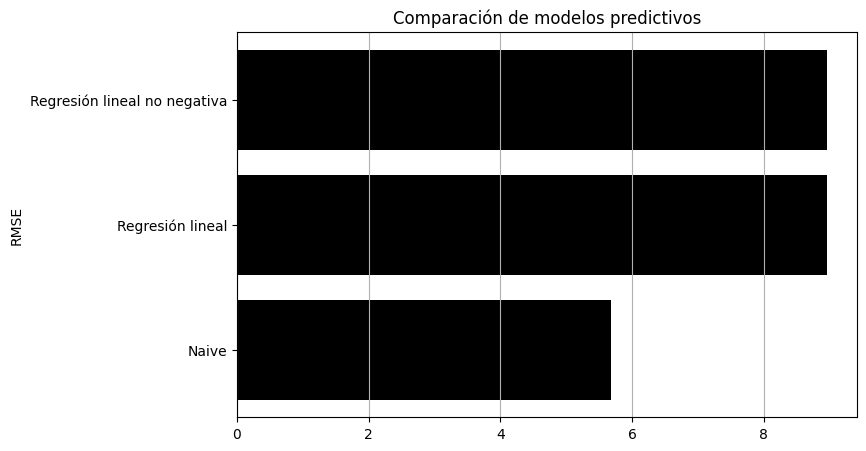

In [24]:
plt.figure(figsize=(8, 5))

plt.barh(df_metricas["modelo"], df_metricas["RMSE"], color='black')

plt.ylabel("RMSE")
plt.title("Comparación de modelos predictivos")
plt.grid(axis="x")

plt.show()

In [25]:
df_test["pred_lr"] = pred_lr
df_test["pred_lr_no_neg"] = pred_lr_no_neg

In [26]:
df_test[["SEMANA_DIAG","casos_siguiente_semana","pred_naive","pred_lr_no_neg"]]

,SEMANA_DIAG,casos_siguiente_semana,pred_naive,pred_lr_no_neg
39,2025-12-22,0.0,6,13.196395
40,2025-12-29,0.0,0,7.307702
41,2026-01-05,4.0,0,6.646276
42,2026-01-12,3.0,4,10.910105
43,2026-01-19,1.0,3,10.591934
44,2026-01-26,3.0,1,8.326342
45,2026-02-02,5.0,3,9.980831
46,2026-02-09,3.0,5,12.205401
47,2026-02-16,3.0,3,10.467694
48,2026-02-23,14.0,3,10.014249


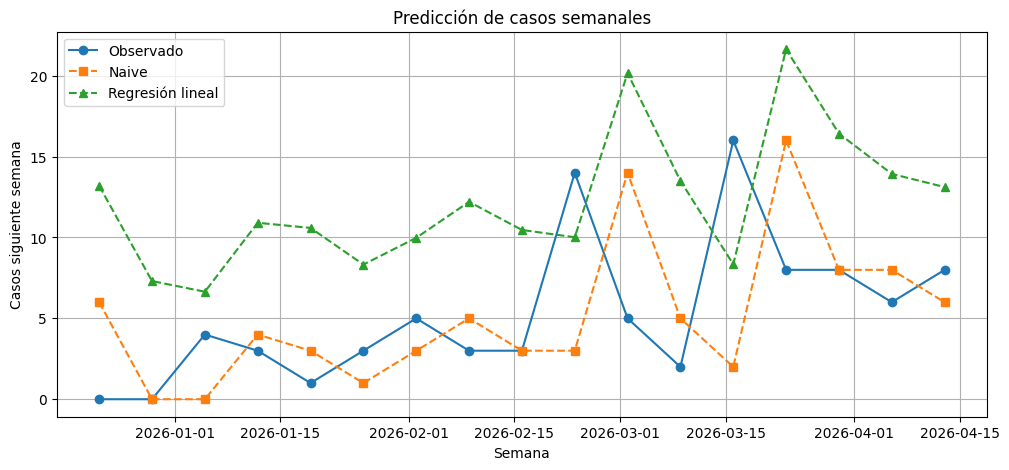

In [91]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_test["SEMANA_DIAG"],
    df_test["casos_siguiente_semana"],
    marker="o",
    label="Observado"
)

plt.plot(
    df_test["SEMANA_DIAG"],
    df_test["pred_naive"],
    marker="s",
    linestyle="--",
    label="Naive"
)

plt.plot(
    df_test["SEMANA_DIAG"],
    df_test["pred_lr_no_neg"],
    marker="^",
    linestyle="--",
    label="Regresión lineal"
)

plt.xlabel("Semana")
plt.ylabel("Casos siguiente semana")
plt.title("Predicción de casos semanales")
plt.legend()
plt.grid()

plt.show()

## Interpretación de coeficientes

In [27]:
df_coef = pd.DataFrame({
    "variable": variables_predictoras,
    "coeficiente": modelo_lr.coef_
})

df_coef = df_coef.sort_values("coeficiente", ascending=False)

df_coef

,variable,coeficiente
0,casos_semana,0.589449
1,lag_1,0.334255
6,cambio_semanal,0.255194
4,promedio_movil_3,0.250337
3,lag_3,0.025032
5,promedio_movil_5,-0.110083
2,lag_2,-0.172694


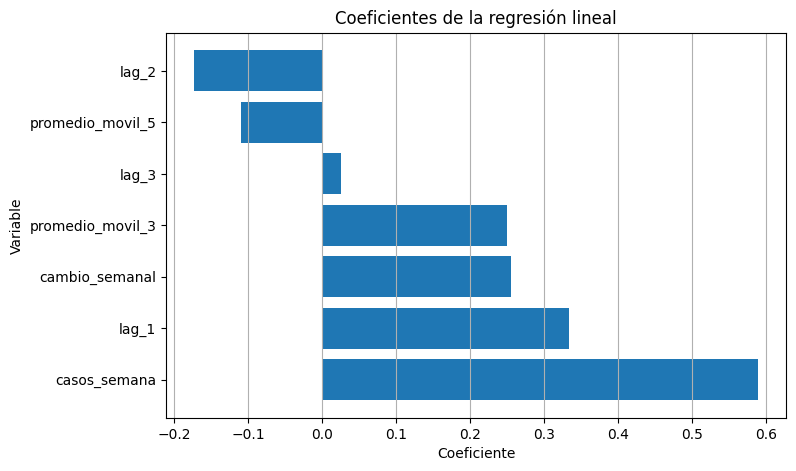

In [28]:
plt.figure(figsize=(8, 5))

plt.barh(df_coef["variable"], df_coef["coeficiente"])

plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.title("Coeficientes de la regresión lineal")
plt.grid(axis="x")

plt.show()

Matemáticamente, cada coeficiente nos dice **cuánto cambiará nuestra predicción ($C_{t+1}$) por cada unidad que aumente esa variable en particular, asumiendo que todas las demás variables se mantienen estrictamente constantes.**


* **`casos_semana` (0.589):** Es el predictor más fuerte. Nos indica que por cada caso adicional confirmado en la semana actual, el modelo proyecta aproximadamente **0.59 casos extra** para la semana siguiente.
* **`lag_1` (0.334):** La inercia de la semana pasada también es vital. Por cada caso que hubo la semana anterior, se suman $\approx 0.33$ casos a la predicción futura.


* **`cambio_semanal` (0.255):** Un valor positivo fuerte. Esto significa que si la curva viene en un ascenso pronunciado (aceleración), el modelo penaliza hacia arriba, prediciendo aún más casos.
* **`promedio_movil_3` (0.250):** Actúa como un soporte de tendencia subyacente positiva.


¿Por qué `lag_2` (-0.172) y `promedio_movil_5` (-0.110) tienen signos negativos? 
Esto es muy probablemente un efecto de **multicolinealidad:** Como todas las variables están altamente correlacionadas entre sí (el `promedio_movil_5` se calcula usando los lags), el algoritmo de Mínimos Cuadrados (OLS) a veces asigna **pesos negativos para contrarrestar y balancear** la sobreestimación que generarían los coeficientes positivos tan altos de `casos_semana` y `lag_1`. Actúan como "frenos matemáticos" para que la predicción no explote hacia el infinito.


**Conclusión epidemiológica:** La transmisión del sarampión tiene una memoria a muy corto plazo fuerte. Lo que ocurre en los últimos 14 días dicta casi toda la tendencia inmediata.

## Errores por semana

In [94]:
df_test["error_lr"] = (
    df_test["casos_siguiente_semana"]
    - df_test["pred_lr_no_neg"]
)

df_test["abs_error_lr"] = np.abs(df_test["error_lr"])

df_test[[
    "SEMANA_DIAG",
    "casos_siguiente_semana",
    "pred_lr_no_neg",
    "error_lr",
    "abs_error_lr"
]].sort_values("abs_error_lr", ascending=False)

,SEMANA_DIAG,casos_siguiente_semana,pred_lr_no_neg,error_lr,abs_error_lr
49,2026-03-02,5.0,20.165563,-15.165563,15.165563
52,2026-03-23,8.0,21.641822,-13.641822,13.641822
39,2025-12-22,0.0,13.196395,-13.196395,13.196395
50,2026-03-09,2.0,13.506241,-11.506241,11.506241
43,2026-01-19,1.0,10.591934,-9.591934,9.591934
46,2026-02-09,3.0,12.205401,-9.205401,9.205401
53,2026-03-30,8.0,16.424580,-8.424580,8.424580
54,2026-04-06,6.0,13.932058,-7.932058,7.932058
42,2026-01-12,3.0,10.910105,-7.910105,7.910105
51,2026-03-16,16.0,8.343739,7.656261,7.656261


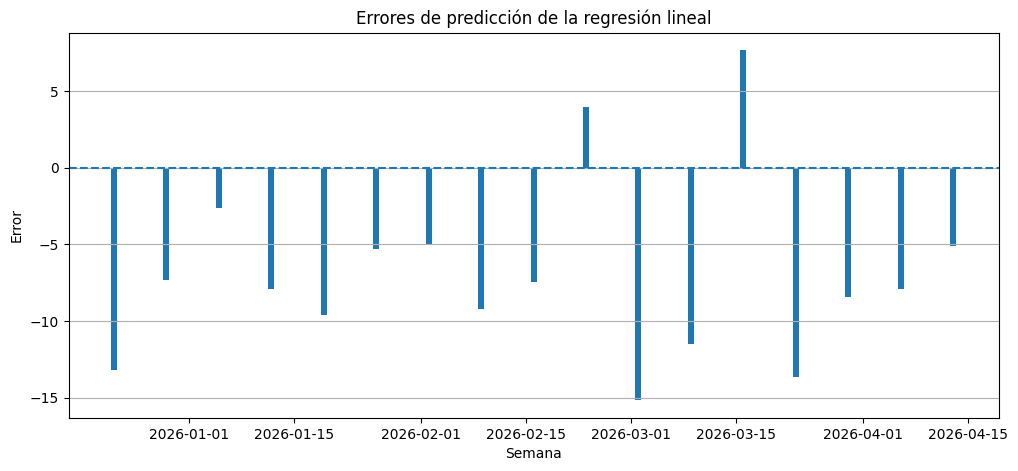

In [95]:
plt.figure(figsize=(12, 5))

plt.axhline(y=0, linestyle="--")

plt.bar(
    df_test["SEMANA_DIAG"],
    df_test["error_lr"]
)

plt.xlabel("Semana")
plt.ylabel("Error")
plt.title("Errores de predicción de la regresión lineal")
plt.grid(axis="y")

plt.show()

### Interpretación de la comparación de modelos

El modelo ingenuo obtuvo un MAE de 4.00 y un RMSE de 5.68, mientras que la regresión lineal obtuvo un MAE de 8.30 y un RMSE de 8.96. Como ambas métricas penalizan el error de predicción y valores más pequeños indican mejor desempeño, el modelo ingenuo tuvo mejor rendimiento en el conjunto de prueba.

Esto significa que, para esta serie y esta partición temporal, predecir los casos de la siguiente semana como iguales a los casos de la semana actual fue más efectivo que usar una regresión lineal con rezagos y promedios móviles.

Este resultado muestra que un modelo más complejo no necesariamente produce mejores predicciones. En series epidemiológicas cortas, con fases muy marcadas del brote y variables altamente correlacionadas entre sí, un modelo simple puede ser una referencia difícil de superar.